In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")

colori = sns.color_palette("pastel")

df_info=df["info"].copy()
df_info

,tipologia,modello,ore impiegate,prezzo,peso,design mio,perline,rimaste,regalate
0,ciondolo,albero,8.0,50,NaN,True,True,0.0,1.0
1,ciondolo,albero semplice,4.5,35,7.35,True,False,1.0,0.0
2,orecchini,spirali con raggi,2.0,20,2.80,True,True,0.0,1.0
3,orecchini,pesci,1.0,15,2.90,False,False,1.0,2.0
4,orecchini,sole-luna,1.5,15,1.90,True,True,1.0,1.0
...,...,...,...,...,...,...,...,...,...
79,ciondolo,spirale per tania,3.5,30,NaN,True,False,0.0,0.0
80,ciondolo,trischele bonus,4.0,30,3.80,True,False,1.0,0.0
81,ciondolo,ranelle,3.0,25,5.00,True,False,1.0,0.0
82,orecchini,triangolo,2.0,20,3.00,True,False,1.0,0.0


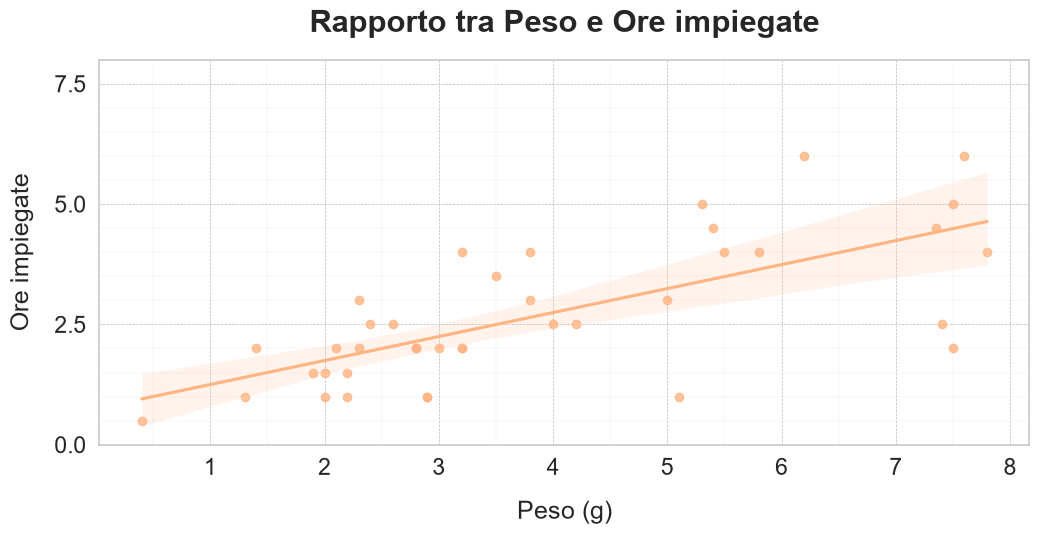

In [7]:
sns.set(style="whitegrid", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 5))
limite = 8

df_no_outlier = df_info[df_info["peso"] <= limite]

sns.regplot(
    data=df_no_outlier, 
    x="peso", 
    y="ore impiegate", 
    ax=ax, 
    color=colori[1],
)

ax.set_facecolor("#FFFFFF")
ax.grid(True, color="#BBBBBB", linewidth=0.5, linestyle="--")
ax.grid(True, axis='y', which='minor', linewidth=0.3, linestyle=":")
ax.grid(True, axis='x', which='minor', linewidth=0.3, linestyle=":")
ax.yaxis.set_major_locator(plt.MultipleLocator(2.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(0, limite)

ax.set_title("Rapporto tra Peso e Ore impiegate", pad=20, fontsize=22, fontweight="bold")
ax.set_xlabel("Peso (g)", fontsize=18, fontweight="normal", labelpad=15)
ax.set_ylabel("Ore impiegate", fontsize=18, fontweight="normal", labelpad=15)

plt.savefig("Immagini/Peso-ore.svg", bbox_inches="tight", pad_inches=0.1, transparent=False)
plt.savefig("Immagini/Peso-ore.png", bbox_inches="tight", pad_inches=0.1, transparent=False)

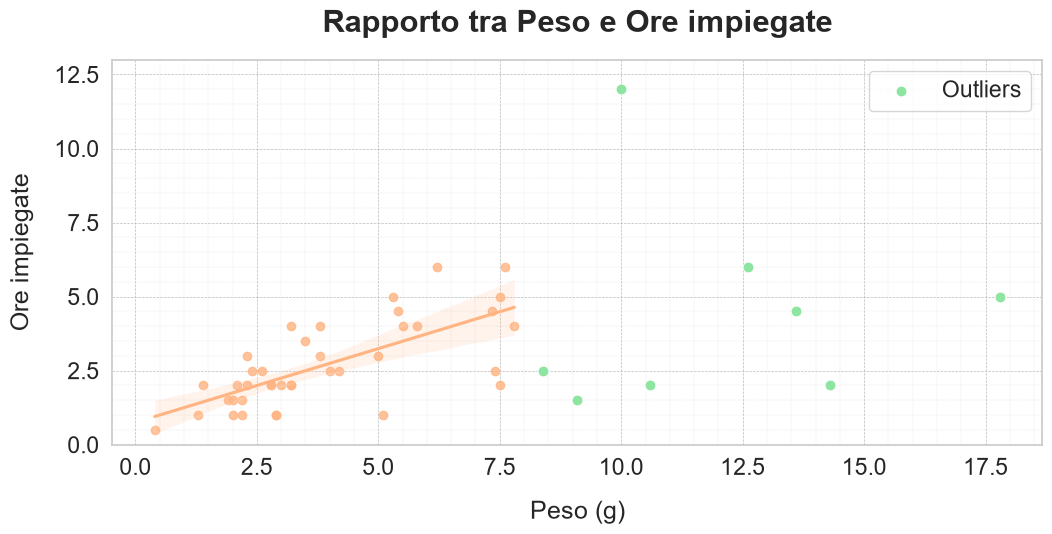

In [8]:
sns.set(style="whitegrid", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 5))
limite = 8

df_no_outlier = df_info[df_info["peso"] <= limite]
df_outlier = df_info[df_info["peso"] > limite]

sns.scatterplot(
    data=df_outlier,
    x="peso",
    y="ore impiegate",
    color=colori[2],
    s=60,
    label="Outliers"
)

sns.regplot(
    data=df_no_outlier, 
    x="peso", 
    y="ore impiegate", 
    ax=ax, 
    color=colori[1]
)

ax.set_facecolor("#FFFFFF")
ax.grid(True, color="#BBBBBB", linewidth=0.5, linestyle="--")
ax.grid(True, axis='y', which='minor', linewidth=0.3, linestyle=":")
ax.grid(True, axis='x', which='minor', linewidth=0.3, linestyle=":")
ax.yaxis.set_major_locator(plt.MultipleLocator(2.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(0, 13)

ax.set_title("Rapporto tra Peso e Ore impiegate", pad=20, fontsize=22, fontweight="bold")
ax.set_xlabel("Peso (g)", fontsize=18, fontweight="normal", labelpad=15)
ax.set_ylabel("Ore impiegate", fontsize=18, fontweight="normal", labelpad=15)

plt.savefig("Immagini/Peso-ore-A.svg", bbox_inches="tight", pad_inches=0.1, transparent=False)
plt.savefig("Immagini/Peso-ore-A.png", bbox_inches="tight", pad_inches=0.1, transparent=False)

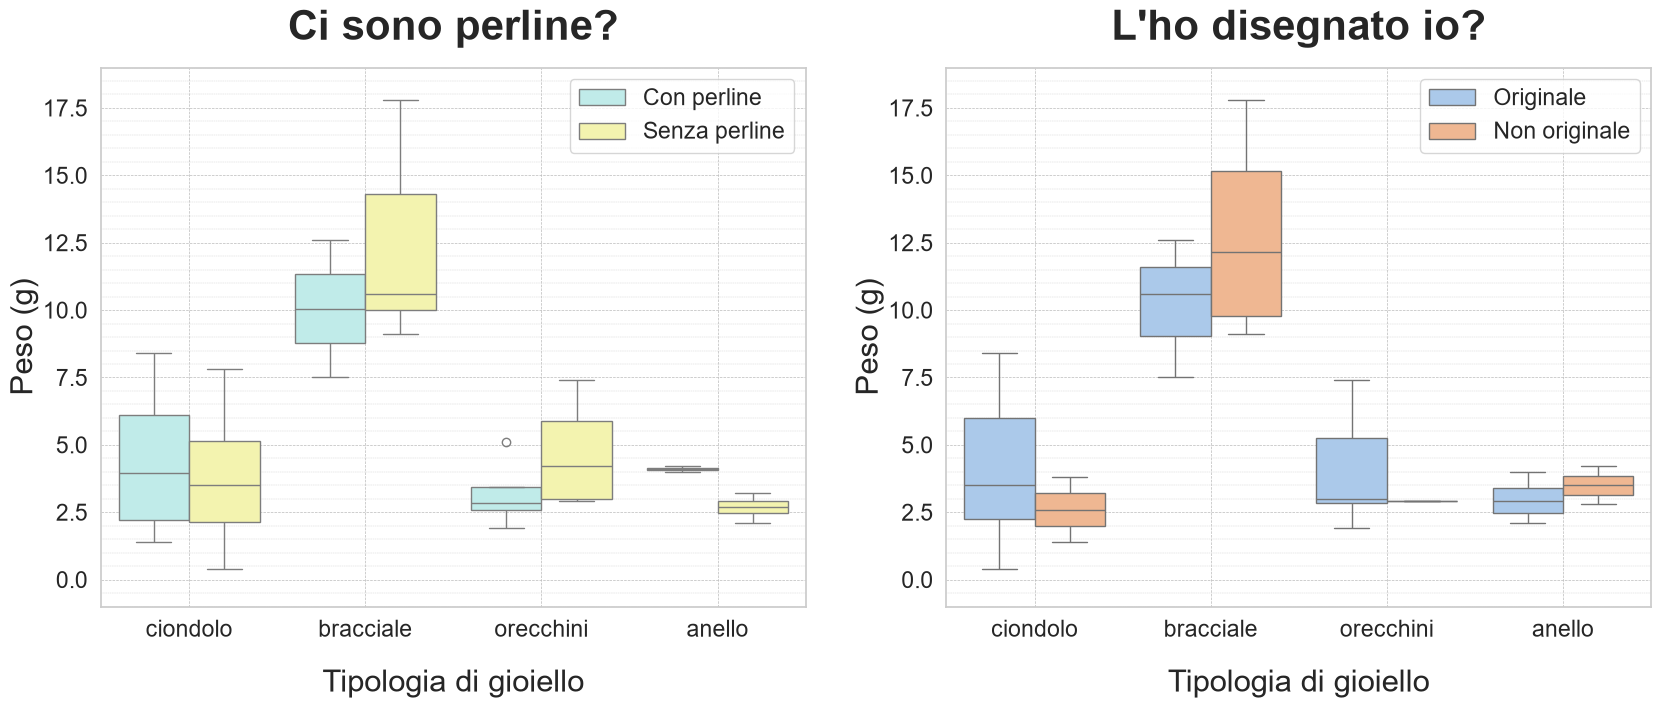

In [9]:
#GRAFICO 3
#grafico della distribuzione dei pesi dei vari oggetti
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 7))
sns.set(style = "whitegrid", font_scale = 1.5)

ordine = ["ciondolo", "bracciale", "orecchini", "anello"]
#ATTENZIONE STIAMO ANDANDO A TRASCURARE LA CATEGORIA ALTRO

df_info["perline_testo"] = df_info["perline"].map({True: "Con perline", False: "Senza perline"})

sns.boxplot(
    ax=ax1,
    data=df_info,
    x="tipologia",
    y="peso",
    order=ordine,
    hue="perline_testo",
    hue_order=["Con perline", "Senza perline"],
    palette={"Con perline": colori[9], "Senza perline": colori[8]}
)

ax1.set_facecolor("#FFFFFF")

ax1.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax1.grid(True, axis = "y", which = "minor", linewidth = 0.3, linestyle="--")

ax1.set_title("Ci sono perline?", pad = 20, fontsize = 30, fontweight = "bold")
ax1.set_xlabel("Tipologia di gioiello", fontsize = 22, fontweight = "normal", labelpad = 20)
ax1.set_ylabel("Peso (g)", fontsize = 22, fontweight = "normal", labelpad = 3)

ax1.legend(loc="upper right")

ax1.yaxis.set_major_locator(plt.MultipleLocator(2.5))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax1.set_ylim(-1, 19)

# '''''''

df_info["design_testo"] = df_info["design mio"].map({True: "Originale", False: "Non originale"})

sns.boxplot(
    ax=ax2,
    data=df_info,
    x="tipologia",
    y="peso",
    order=ordine,
    hue="design_testo",
    hue_order=["Originale", "Non originale"],
    palette={"Originale": colori[0], "Non originale": colori[1]}
)
ax2.set_facecolor("#FFFFFF")

ax2.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax2.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

ax2.set_title("L'ho disegnato io?", pad = 20, fontsize = 30, fontweight = "bold")
ax2.set_xlabel("Tipologia di gioiello", fontsize = 22, fontweight = "normal", labelpad = 20)
ax2.set_ylabel("Peso (g)", fontsize = 22, fontweight = "normal", labelpad = 3)

ax2.yaxis.set_major_locator(plt.MultipleLocator(2.5))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax2.set_ylim(-1, 19)
ax2.legend(loc="upper right")

plt.savefig("Immagini/Peso.svg", bbox_inches = "tight", pad_inches = 0.1, transparent = False)
plt.savefig("Immagini/Peso.png", bbox_inches = "tight", pad_inches = 0.1, transparent = False)